In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

# FULL Implementation

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

In [3]:
# path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/results/ting_v1_psnex_map___2025.03.12_18.23.11.20_ting_results.csv'
map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54'
# df_ting = pd.read_csv(path_ting)
# df_ting.head()

In [4]:
# CTC 44 PFQNM. THIS
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)
bool_error, mismatch_indices = maps.check_map_indice_integrity(df_dict_tdms, map_x_pix, map_y_pix)
if bool_error:
    x_pos_1d, y_pos_1d, curve_index = maps.generate_xy_map_positions(map_x_pix=map_x_pix, map_y_pix=map_y_pix)
    x_indices = x_pos_1d
    y_indices = y_pos_1d
    print ('Map indices were regenerated due to integrity error')   

    # compute the time difference between files, and sort time from start to finish.
    # create a sorted dataframe based on time
    # Does not have file_id column
    df_time = maps.compute_time_difference(map_path)

    # Remove duplicates from df_time based on filepath (keep first occurrence)
    df_time = df_time.drop_duplicates(subset='filepath', keep='first')

    # Merge based on filepath - this should now be 1:1
    df_merged_tdms = pd.merge(df_dict_tdms, df_time, on='filepath', how='left')

    # create copy of df_merged_tdms to avoid SettingWithCopyWarning
    df_merged_tdms_copy = df_merged_tdms.copy()

    # # merge def_ting to df_merged_tdms based on filepath
    # df_merged_tdms_copy = pd.merge(df_merged_tdms_copy, df_ting, on='file_id', how='left')

    # # insert x_indices and y_indices and curve index into df_merged_tdms
    df_merged_tdms_copy['x_index'] = x_indices
    df_merged_tdms_copy['y_index'] = y_indices
    df_merged_tdms_copy['curve_index'] = curve_index

    # Check if we have the expected number of rows
    print(f"df_map rows: {len(df_dict_tdms)}")
    print(f"df_time rows: {len(df_time)}")
    print(f"df_merged_tdms rows: {len(df_merged_tdms)}")

# of files analyzed: 1024, closest shape: 32 x 32
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detec

In [5]:
# df_merged_tdms_copy.head()

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
y_sens_um: 3.96, x_sens_um: 5.685


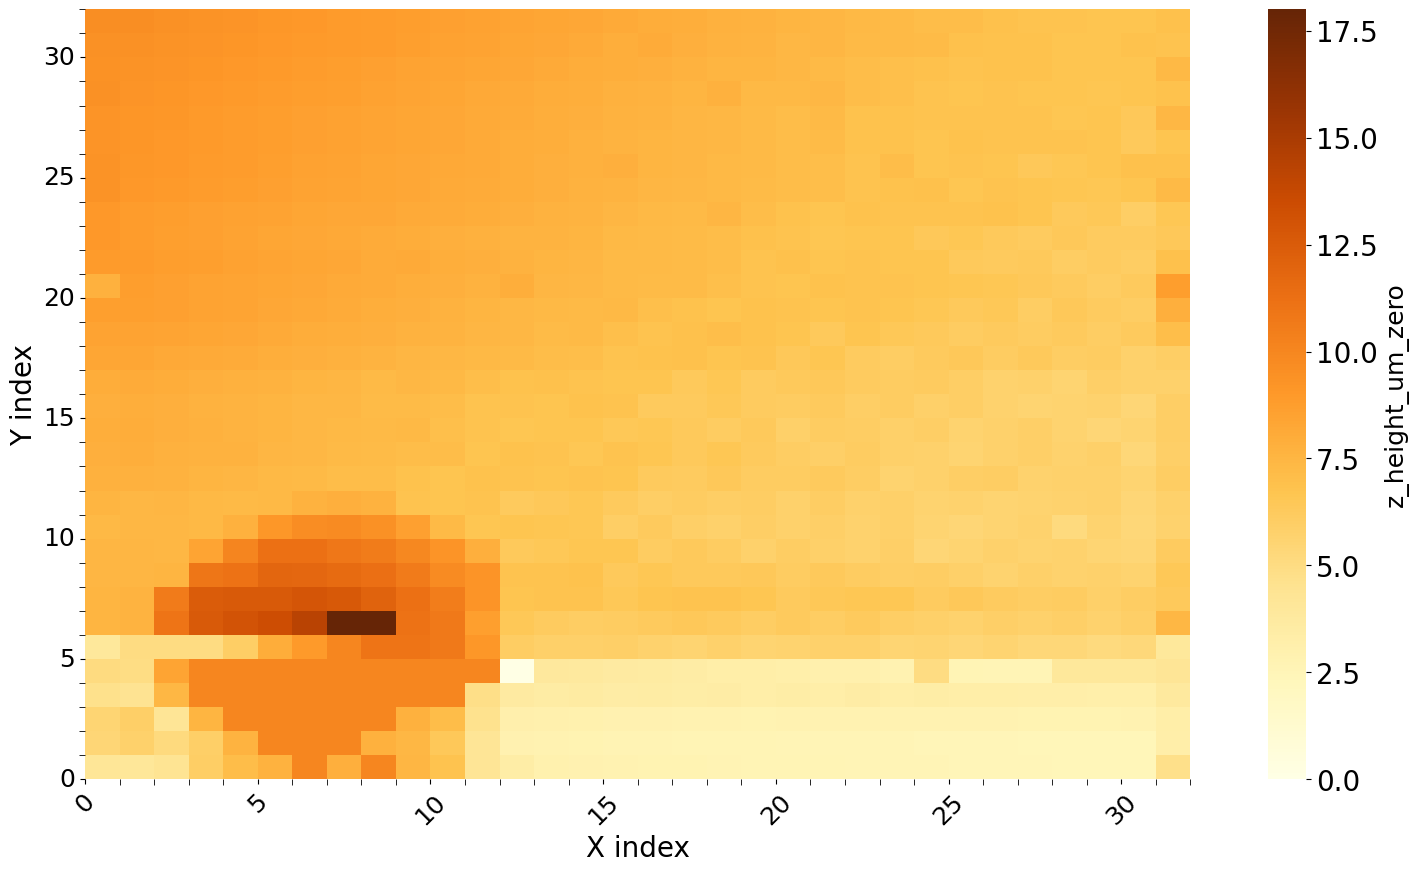

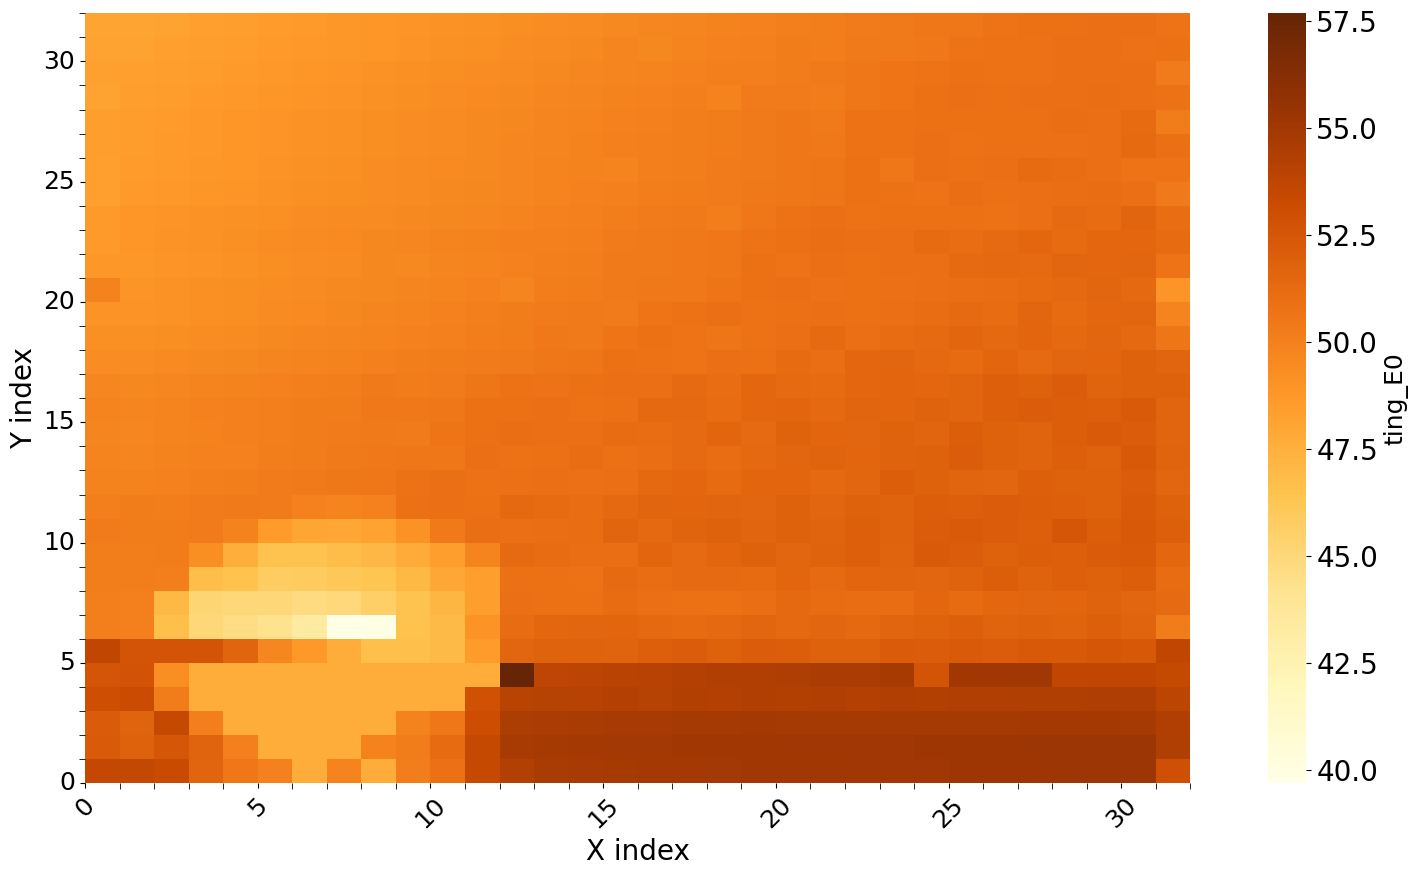

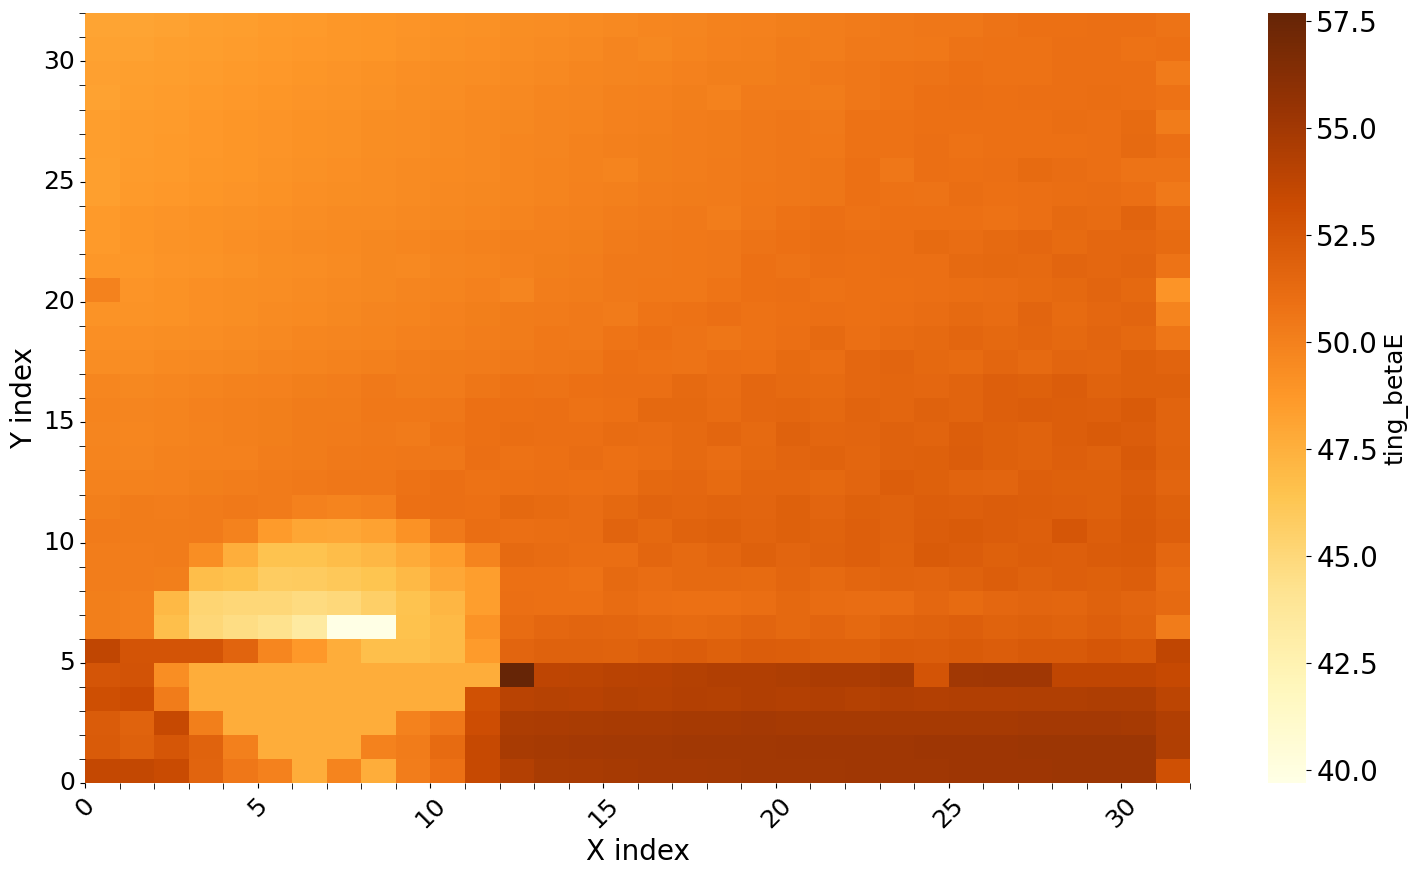

In [6]:
key = "ting_E0"
key = "z_height_um_zero"
keys_to_plot = ['z_height_um_zero', 'ting_E0', 'ting_betaE']

for key in keys_to_plot:
    _ = maps.create_heatmap(df_merged_tdms_copy,value_key = key, annot=False)

/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2258: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')


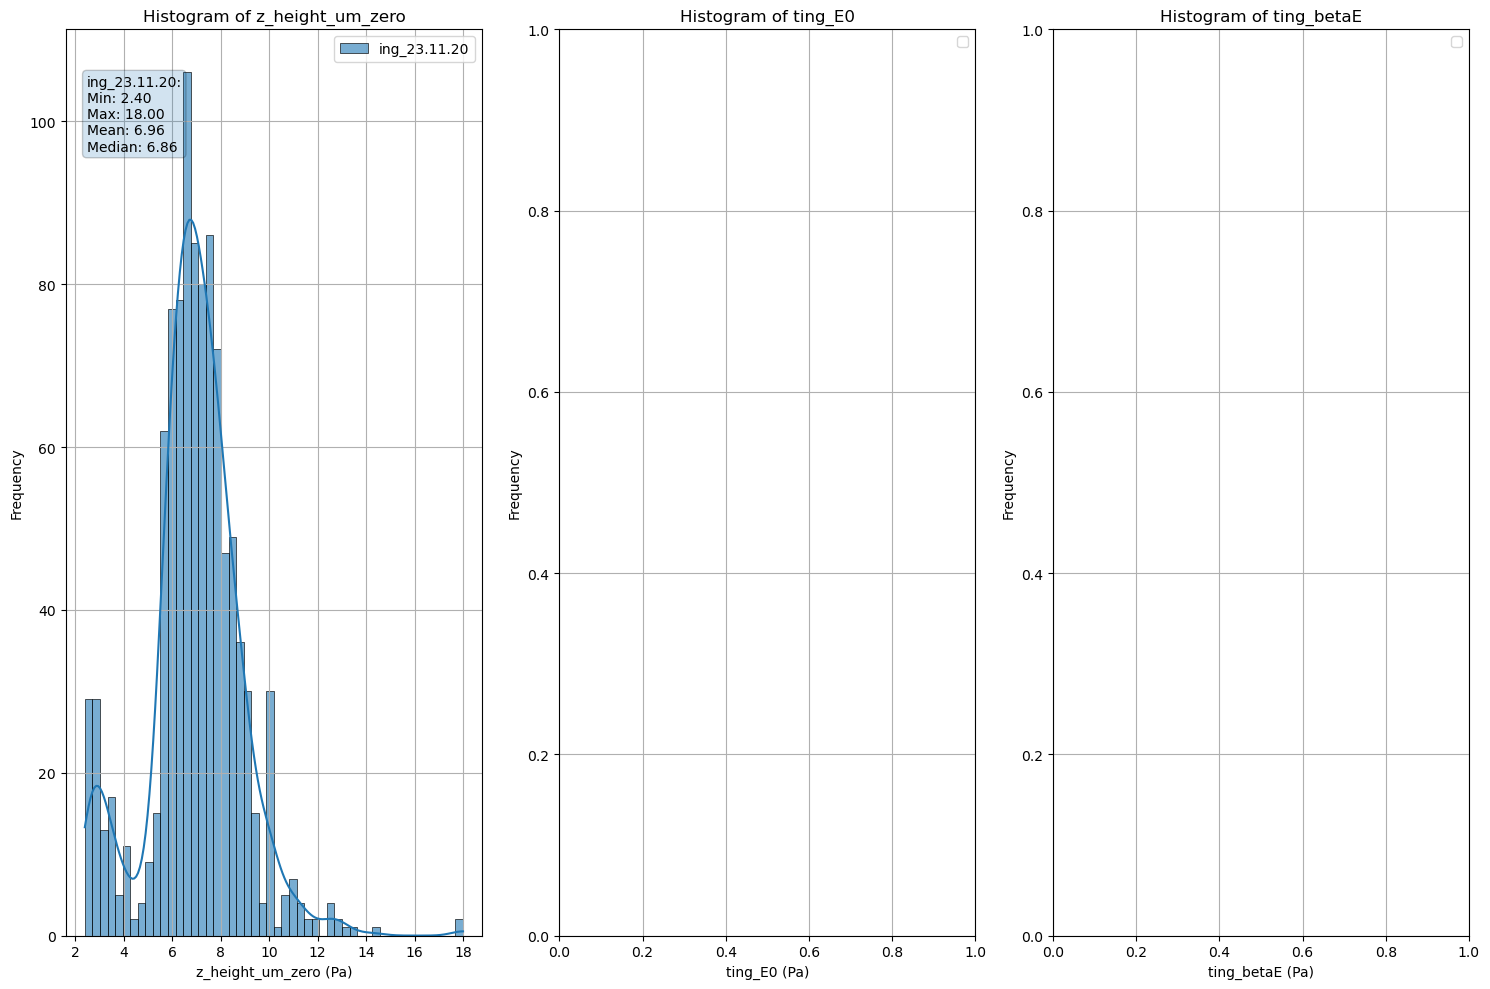

(<Figure size 1500x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Histogram of z_height_um_zero'}, xlabel='z_height_um_zero (Pa)', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of ting_E0'}, xlabel='ting_E0 (Pa)', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of ting_betaE'}, xlabel='ting_betaE (Pa)', ylabel='Frequency'>],
       dtype=object))

In [7]:
# plot the distributions of the target keys
dataframes = [(df_merged_tdms_copy, "ing_23.11.20")]
maps.create_scatter_comparison(dataframes, keys_to_plot, filter_range=(0, 4000), figsize=(15, 10))


In [9]:
import pyfmreader as pyfm
import glob
import os

In [10]:
map_path = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/'

# get first tdms file
tdms_files = glob.glob(os.path.join(map_path, '*.tdms'))

In [12]:
# 2. Load one of the test files
PSNEX_MAP_PATH = map_path

PSNEX_MAP_FILE = pyfm.loadfile(tdms_files[0])

type(PSNEX_MAP_FILE)

detected PS-NEX map folder


pyfmreader.uff.UFF

In [13]:
# 3. Get file metadata
metadata = PSNEX_MAP_FILE.filemetadata

for key, item in metadata.items():
    print(f"{key} : {item}\n") 

file_path : /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.50.46.00.tdms

Entry_filename : fcurve___2025.05.30_17.50.46.00.tdms

file_size_bytes : 727860

Entry_date : 20250530

Entry_tot_nb_curve : 0

Entry_experiment_name : AC40_CTC44_3D

User : Lorenzo

psnex_file_format_version : 0

psnex_software_version : 1.4.2

Experimental_instrument : PSnex_HSAFM

instrument_clorckrate_(Mhz) : 40.0

instrument_tick_time_(us) : 0.025

instrument_tick_time_(s) : 2.5e-08

instrument_model : Empty

instrument_scanner : PI_Z_stage

sample_name : CTC44_3D

sample_species : CTC44

user : Lorenzo

UFF_code : _1_2_3_4_5

Entry_UFF_version : 0

num_segments : 3

tip_half_angle : 0.0

tip_geometry : 

tip_height_m : 0.0

tip_radius_m : 0.0

invOLS_(nm/V) : 24.0

defl_sens_nmbyV : 24.0

system_mount_angle_(deg) : 0.0

system_X_piezo_gain : 1.0

system_X_piezo_sensitivity_(nm/V) : 5685.0

system_Y_piezo_gain : 1.0

system_Y_piezo_sensitivity_(nm/V) : 3960.0



In [14]:

piezoimg = PSNEX_MAP_FILE.getpiezoimg()

plt.figure(figsize=(10,10))
plt.imshow(piezoimg[:, :, 0], cmap='afmhot', origin='lower')
plt.show()

PS-NEX piezo image loading.
This is a psnex mapping file! 
CSV file(s) found: ['/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/psnex_map___2025.05.30_17.44.50.71_AC40_CTC44_3D.csv']


KeyError: 'num_y_pixels'